# 🚛 Complete Concrete Mixer Truck Detection Pipeline
## YOLO-World Auto-Labeling → OBB Training → Rotation Detection

**Features:**
- ✅ YOLO-World zero-shot detection for mixer drums
- ✅ OBB (Oriented Bounding Box) with angle detection
- ✅ Two-stage training with freeze backbone
- ✅ MLflow experiment tracking
- ✅ Rotation detection with Optical Flow + SSIM
- ✅ Complete pipeline in single notebook

**Model:** yolo26n-obb.pt  
**Datasets:** Mixer.yolo26 + concrete mixed truck.yolo26

## 📦 Installation & Imports

In [22]:
# Install required packages
!pip install -q ultralytics opencv-python pyyaml mlflow scikit-image ipywidgets

print("✅ Packages installed successfully!")

✅ Packages installed successfully!


In [23]:
# Import all required libraries
import os
import cv2
import numpy as np
import yaml
import shutil
import zipfile
import mlflow
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional
from ultralytics import YOLO, YOLOWorld
from skimage.metrics import structural_similarity as ssim
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

print("✅ All imports successful!")

✅ All imports successful!


## ⚙️ Configuration

In [24]:
# Configuration dataclasses
@dataclass
class Config:
    """Complete pipeline configuration"""
    # Paths
    data_dir: str = "./data"
    merged_dir: str = "./merged_dataset_obb"
    auto_labeled_dir: str = "./auto_labeled"
    mlruns_dir: str = "./mlruns"
    
    # Dataset
    dataset_1_name: str = "Mixer.yolo26"
    dataset_2_name: str = "concrete mixed truck.yolo26"
    classes: Dict[int, str] = None
    num_classes: int = 2
    
    # Model
    model_name: str = "yolo26n-obb.pt"
    input_size: int = 640
    batch_size: int = 4
    epochs: int = 20
    freeze_epochs: int = 10
    
    # YOLO-World
    yoloworld_model: str = "yolov8x-worldv2.pt"
    target_class: str = "concrete mixer drum"
    conf_threshold: float = 0.3
    max_label_images: int = 100
    
    # MLflow
    experiment_name: str = "concrete_mixer_obb_detection"
    
    # Rotation Detection
    flow_magnitude_threshold: float = 2.0
    ssim_threshold: float = 0.85
    
    def __post_init__(self):
        self.classes = {0: 'truck', 1: 'mixer_drum'}

# Initialize config
config = Config()
print("✅ Configuration loaded")
print(f"   Model: {config.model_name}")
print(f"   Classes: {config.classes}")
print(f"   Epochs: {config.epochs}")

✅ Configuration loaded
   Model: yolo26n-obb.pt
   Classes: {0: 'truck', 1: 'mixer_drum'}
   Epochs: 20


## 🎯 PHASE 1: YOLO-World Auto-Labeling with OBB

In [25]:
class YOLOWorldOBBLabeler:
    """YOLO-World labeler for Multi-Class OBB (truck & concrete mixer drum)"""
    
    def __init__(self, model_name="yolov8x-worldv2.pt"):
        self.model_name = model_name
        self.model = YOLOWorld(model_name)
    
    def load_model(self, classes: List[str]):
        """Load YOLO-World with multiple classes"""
        print(f"🚀 Loading YOLO-World with target classes: {classes}")
        self.model.set_classes(classes)
        self.target_classes = classes
        print(f"✅ Model ready.")
    
    def get_obb_corners(self, img, bbox):
        """Extract 4 corners (Normalized 0.0-1.0) for OBB format"""
        h, w = img.shape[:2]
        x_center, y_center, width, height = bbox
        
        # Calculate corners based on box center and dimensions
        x1, y1 = x_center - width/2, y_center - height/2
        x2, y2 = x_center + width/2, y_center - height/2
        x3, y3 = x_center + width/2, y_center + height/2
        x4, y4 = x_center - width/2, y_center + height/2
        
        # Clip to ensure values are within [0, 1]
        corners = [max(0.0, min(1.0, c)) for c in [x1, y1, x2, y2, x3, y3, x4, y4]]
        return corners

    def detect_and_label(self, image_path, conf_threshold=0.15):
        """Detect multiple objects and return OBB labels with dynamic class IDs"""
        img = cv2.imread(str(image_path))
        if img is None: return []
        
        h, w = img.shape[:2]
        results = self.model.predict(image_path, conf=conf_threshold, verbose=False)
        
        obb_labels = []
        for result in results:
            if hasattr(result, 'boxes') and len(result.boxes) > 0:
                for box in result.boxes:
                    # ✅ ดึง Class ID จริงที่โมเดลทายได้ (0=truck, 1=concrete mixer drum)
                    current_cls_id = int(box.cls[0].item())
                    
                    xyxy = box.xyxy[0].cpu().numpy()
                    cx = ((xyxy[0] + xyxy[2]) / 2) / w
                    cy = ((xyxy[1] + xyxy[3]) / 2) / h
                    bw = (xyxy[2] - xyxy[0]) / w
                    bh = (xyxy[3] - xyxy[1]) / h
                    
                    corners = self.get_obb_corners(img, [cx, cy, bw, bh])
                    corners_str = " ".join([f"{c:.6f}" for c in corners])
                    
                    # Format: class_id x1 y1 x2 y2 x3 y3 x4 y4 (Total 9 values)
                    obb_labels.append(f"{current_cls_id} {corners_str}")
        
        return obb_labels
    
    def auto_label_dataset(self, dataset_path, output_path, target_classes, conf_threshold=0.15):
        self.load_model(target_classes)
        dataset_path = Path(dataset_path)
        output_path = Path(output_path)
        
        (output_path / 'train' / 'images').mkdir(parents=True, exist_ok=True)
        (output_path / 'train' / 'labels').mkdir(parents=True, exist_ok=True)
        
        # Scan for all image extensions
        image_files = []
        for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.PNG']:
            image_files.extend(list((dataset_path / 'train' / 'images').glob(ext)))
            
        print(f"📦 Found {len(image_files)} images. Processing...")
        labeled_count = 0
        
        for img_file in tqdm(image_files, desc="Auto-labeling"):
            labels = self.detect_and_label(img_file, conf_threshold)
            if labels:
                shutil.copy(img_file, output_path / 'train' / 'images' / img_file.name)
                with open(output_path / 'train' / 'labels' / f"{img_file.stem}.txt", 'w') as f:
                    f.write('\n'.join(labels))
                labeled_count += 1
        
        print(f"✅ Done! Labeled {labeled_count}/{len(image_files)} images.")
        return output_path

In [26]:
# --- EXECUTION: PHASE 1 & 2 ---
labeler = YOLOWorldOBBLabeler()
# 🚚 กำหนด 2 คลาสที่ต้องการ (เรียงลำดับให้ตรงกับที่ต้องการใน YAML)
target_classes = ["truck", "concrete mixer drum"] 

# รัน Auto-labeling (ลด conf_threshold เพื่อให้ได้ Data เยอะขึ้น)
auto_labeled_path = labeler.auto_label_dataset(
    dataset_path="./mixer_data", # ปรับ Path ตามของคุณ
    output_path="./auto_labeled",
    target_classes=target_classes,
    conf_threshold=0.15 
)

# รัน Data Fusion
fusion = DataFusion()
merged_dir = fusion.merge_datasets(
    [auto_labeled_path, "./mixer_data", "./concrete_data"], 
    "./merged_dataset_obb"
)

# สร้าง YAML พร้อมระบุ 2 คลาส
data_yaml_path = fusion.create_data_yaml(
    merged_dir, 
    classes=target_classes
)

print(f"🚀 Pipeline Ready! Data YAML: {data_yaml_path}")

🚀 Loading YOLO-World with target classes: ['truck', 'concrete mixer drum']
✅ Model ready.
📦 Found 0 images. Processing...


Auto-labeling: 0it [00:00, ?it/s]

✅ Done! Labeled 0/0 images.


Merging Datasets: 0it [00:00, ?it/s]

✅ Successfully merged 0 images.
🚀 Pipeline Ready! Data YAML: merged_dataset_obb\data.yaml


## 📦 PHASE 2: Data Fusion

In [27]:
class DataFusion:
    """Merge datasets and force OBB 9-value format"""
    
    @staticmethod
    def ensure_obb_format(label_path):
        """Convert 5-value YOLO labels to 9-value OBB labels if detected"""
        if not label_path.exists(): return
        with open(label_path, 'r') as f:
            lines = f.readlines()
        
        new_lines = []
        modified = False
        for line in lines:
            parts = line.strip().split()
            if len(parts) == 5:  # Standard: cls cx cy w h
                modified = True
                cls, cx, cy, w, h = map(float, parts)
                # Convert to 4 corners
                x1, y1 = cx - w/2, cy - h/2
                x2, y2 = cx + w/2, cy - h/2
                x3, y3 = cx + w/2, cy + h/2
                x4, y4 = cx - w/2, cy + h/2
                new_lines.append(f"{int(cls)} {x1:.6f} {y1:.6f} {x2:.6f} {y2:.6f} {x3:.6f} {y3:.6f} {x4:.6f} {y4:.6f}")
            else:
                new_lines.append(line.strip())
        
        if modified:
            with open(label_path, 'w') as f:
                f.write('\n'.join(new_lines))

    def merge_datasets(self, dataset_paths, output_dir, split_ratio=0.8):
        output_path = Path(output_dir)
        for s in ['train', 'valid']:
            (output_path / s / 'images').mkdir(parents=True, exist_ok=True)
            (output_path / s / 'labels').mkdir(parents=True, exist_ok=True)
            
        all_pairs = []
        for dp in dataset_paths:
            img_dir = Path(dp) / 'train' / 'images'
            if img_dir.exists():
                imgs = list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png'))
                for img in imgs:
                    lbl = img.parent.parent / 'labels' / f"{img.stem}.txt"
                    if lbl.exists(): all_pairs.append((img, lbl))
        
        random.shuffle(all_pairs)
        split_idx = int(len(all_pairs) * split_ratio)
        
        for i, (img, lbl) in enumerate(tqdm(all_pairs, desc="Merging Datasets")):
            split = 'train' if i < split_idx else 'valid'
            shutil.copy(img, output_path / split / 'images' / img.name)
            new_lbl_path = output_path / split / 'labels' / lbl.name
            shutil.copy(lbl, new_lbl_path)
            self.ensure_obb_format(new_lbl_path) # บังคับ Format OBB
            
        print(f"✅ Successfully merged {len(all_pairs)} images.")
        return output_path

    def create_data_yaml(self, merged_dir, classes, output_name="data.yaml"):
        merged_path = Path(merged_dir)
        data_config = {
            'path': str(merged_path.absolute()),
            'train': 'train/images',
            'val': 'valid/images',
            'nc': len(classes),
            'names': classes
        }
        yaml_path = merged_path / output_name
        with open(yaml_path, 'w') as f:
            yaml.dump(data_config, f, default_flow_style=False)
        return yaml_path

In [28]:
# Extract and merge datasets
data_dir = Path(config.data_dir)

# Extract datasets if needed
dataset_paths = []

# Dataset 1
ds1_path = data_dir / config.dataset_1_name
if not ds1_path.exists():
    zip1 = data_dir / f"{config.dataset_1_name}.zip"
    if zip1.exists():
        DataFusion.extract_zip(zip1, ds1_path)
if ds1_path.exists():
    dataset_paths.append(ds1_path)
    print(f"✅ Dataset 1: {ds1_path}")

# Dataset 2
ds2_path = data_dir / config.dataset_2_name
if not ds2_path.exists():
    zip2 = data_dir / f"{config.dataset_2_name}.zip"
    if zip2.exists():
        DataFusion.extract_zip(zip2, ds2_path)
if ds2_path.exists():
    dataset_paths.append(ds2_path)
    print(f"✅ Dataset 2: {ds2_path}")

# Auto-labeled dataset
if Path(auto_labeled_path).exists():
    dataset_paths.append(auto_labeled_path)
    print(f"✅ Auto-labeled: {auto_labeled_path}")

# Merge all datasets
merged_dir = DataFusion.merge_datasets(dataset_paths, config.merged_dir)

# Create data.yaml
data_yaml_path = DataFusion.create_data_yaml(merged_dir, config.classes)

print(f"\n📁 Merged dataset: {merged_dir}")
print(f"📄 Data YAML: {data_yaml_path}")

✅ Dataset 1: data\Mixer.yolo26
✅ Dataset 2: data\concrete mixed truck.yolo26
✅ Auto-labeled: auto_labeled


TypeError: DataFusion.merge_datasets() missing 1 required positional argument: 'output_dir'

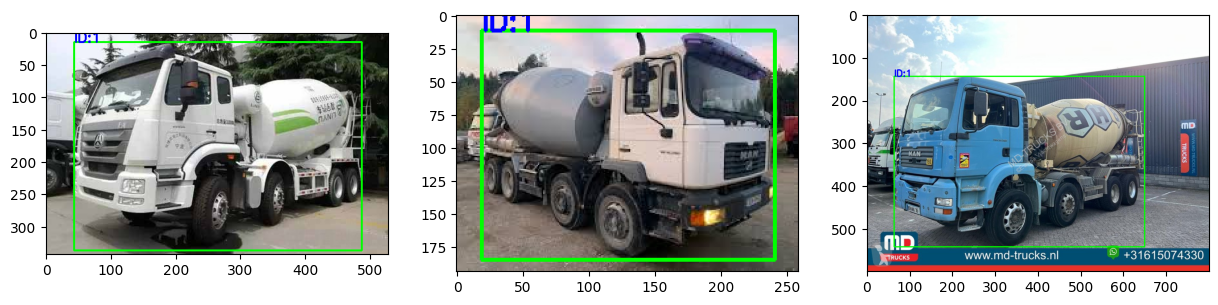

In [ ]:
import matplotlib.pyplot as plt
import random

def verify_labels(path, num=3):
    imgs = list(Path(path).glob('train/images/*.jpg'))
    samples = random.sample(imgs, min(num, len(imgs)))
    fig, axes = plt.subplots(1, len(samples), figsize=(15, 5))
    
    for i, img_p in enumerate(samples):
        img = cv2.imread(str(img_p))
        h, w = img.shape[:2]
        lbl_p = Path(path) / 'train' / 'labels' / f"{img_p.stem}.txt"
        if lbl_p.exists():
            with open(lbl_p, 'r') as f:
                for line in f:
                    d = line.split()
                    pts = np.array([float(x) for x in d[1:]]).reshape(4, 2)
                    pts[:, 0] *= w; pts[:, 1] *= h
                    cv2.polylines(img, [pts.astype(np.int32)], True, (0, 255, 0), 2)
                    cv2.putText(img, f"ID:{d[0]}", tuple(pts[0].astype(int)), 0, 0.7, (255,0,0), 2)
        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.show()

verify_labels('./merged_dataset_obb')

🔍 สุ่มตรวจทั้งหมด 3 ภาพจาก merged_dataset_obb\train\labels


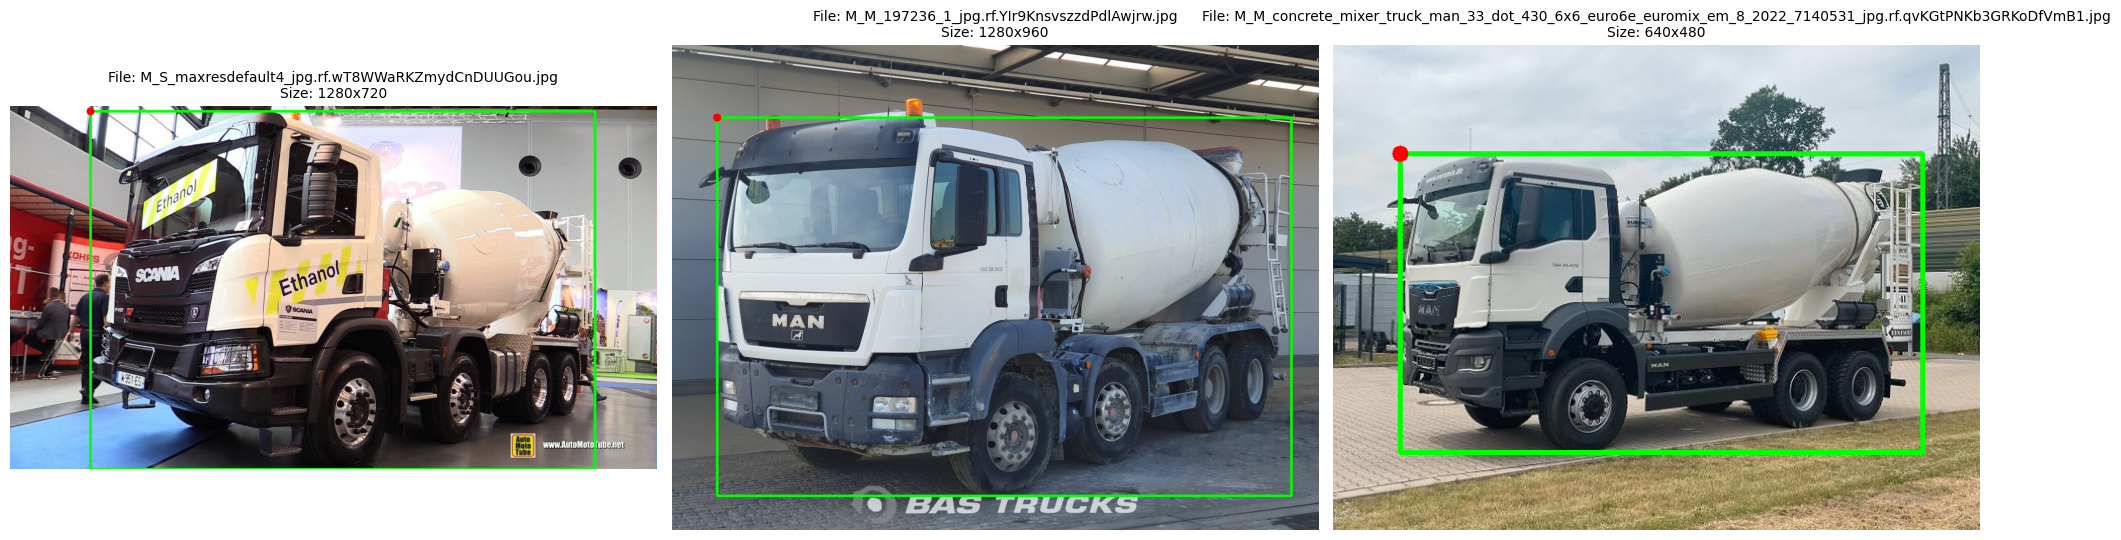

In [ ]:
import matplotlib.pyplot as plt
import random
import cv2
import numpy as np
from pathlib import Path

# บรรทัดนี้สำคัญสำหรับ Jupyter Notebook เพื่อให้ภาพแสดง inline
%matplotlib inline

def visualize_obb_labels(dataset_path, num_samples=3):
    """สุ่มตัวอย่างภาพและวาดกรอบ OBB (8-point) เพื่อตรวจสอบความถูกต้อง"""
    dataset_path = Path(dataset_path)
    img_dir = dataset_path / 'train' / 'images'
    label_dir = dataset_path / 'train' / 'labels'
    
    # ดึงรายชื่อไฟล์ภาพ
    images = list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png')) + list(img_dir.glob('*.jpeg'))
    
    if not images:
        print(f"❌ ไม่พบรูปภาพในโฟลเดอร์: {img_dir}")
        return
        
    samples = random.sample(images, min(num_samples, len(images)))
    print(f"🔍 สุ่มตรวจทั้งหมด {len(samples)} ภาพจาก {label_dir}")
    
    # สร้าง Figure
    fig = plt.figure(figsize=(20, 7))
    
    for i, img_path in enumerate(samples):
        # อ่านภาพด้วย OpenCV
        img = cv2.imread(str(img_path))
        if img is None: continue
        
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape
        
        label_path = label_dir / f"{img_path.stem}.txt"
        
        ax = fig.add_subplot(1, len(samples), i + 1)
        
        if label_path.exists():
            with open(label_path, 'r') as f:
                lines = f.readlines()
                for line in lines:
                    parts = line.strip().split()
                    # ตรวจสอบว่าเป็น OBB (9 ค่า: class + 8 พิกัด)
                    if len(parts) == 9:
                        pts = np.array([float(x) for x in parts[1:]]).reshape(4, 2)
                        # แปลง Normalized -> Pixel
                        pts[:, 0] *= w
                        pts[:, 1] *= h
                        pts = pts.astype(np.int32)
                        
                        # วาดเส้นกรอบ (สีเขียว)
                        cv2.polylines(img, [pts], isClosed=True, color=(0, 255, 0), thickness=3)
                        # จุดเริ่มต้น x1, y1 (สีแดง)
                        cv2.circle(img, tuple(pts[0]), 8, (255, 0, 0), -1)
                    else:
                        print(f"⚠️ ไฟล์ {label_path.name} มีฟอร์แมตไม่ถูกต้อง (มี {len(parts)} ค่า)")
        else:
            print(f"❓ ไม่พบไฟล์ Label สำหรับ: {img_path.name}")
        
        ax.imshow(img)
        ax.set_title(f"File: {img_path.name}\nSize: {w}x{h}", fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# เรียกใช้งาน (เปลี่ยน path ให้ตรงกับโฟลเดอร์ที่มีข้อมูลของคุณ)
# หากคุณเพิ่งรัน Data Fusion เสร็จ ให้ใช้ './merged_dataset_obb'
visualize_obb_labels('./merged_dataset_obb', num_samples=3)

## 🎓 PHASE 3: Two-Stage Training with MLflow

In [ ]:
class OBBTrainer:
    """OBB model trainer with freeze backbone and MLflow tracking"""
    
    def __init__(self, config):
        self.config = config
        self.model = None
    
    def setup_mlflow(self):
        """Setup MLflow tracking"""
        print("\n" + "="*70)
        print("MLFLOW SETUP")
        print("="*70)
        
        os.makedirs(self.config.mlruns_dir, exist_ok=True)
        
        # Fix for Windows: convert path to file:// URI
        tracking_path = os.path.abspath(self.config.mlruns_dir).replace('\\', '/')
        tracking_uri = f"file:///{tracking_path}"
        mlflow.set_tracking_uri(tracking_uri)
        
        try:
            mlflow.create_experiment(self.config.experiment_name)
            print(f"✅ Created experiment: {self.config.experiment_name}")
        except:
            print(f"✅ Using existing experiment: {self.config.experiment_name}")
        
        mlflow.set_experiment(self.config.experiment_name)
        print(f"   MLflow URI: {tracking_uri}")
        print("="*70)
    
    def load_model(self):
        """Load YOLO OBB model"""
        print(f"\nLoading model: {self.config.model_name}")
        self.model = YOLO(self.config.model_name)
        print(f"✅ Model loaded: {type(self.model)}")
    
    def freeze_backbone(self, num_layers=10):
        """Freeze first N layers"""
        print(f"\n🔒 Freezing first {num_layers} layers...")
        
        frozen_count = 0
        for i, (name, param) in enumerate(self.model.model.named_parameters()):
            if i < num_layers:
                param.requires_grad = False
                frozen_count += 1
        
        print(f"✅ Frozen {frozen_count} parameters")
    
    def unfreeze_all(self):
        """Unfreeze all layers"""
        print(f"\n🔓 Unfreezing all layers...")
        
        for param in self.model.model.parameters():
            param.requires_grad = True
        
        print(f"✅ All layers unfrozen")
    
    def count_parameters(self):
        """Count trainable and frozen parameters"""
        total = sum(p.numel() for p in self.model.model.parameters())
        trainable = sum(p.numel() for p in self.model.model.parameters() if p.requires_grad)
        frozen = total - trainable
        
        print(f"\n📊 Model Parameters:")
        print(f"   Total: {total:,}")
        print(f"   Trainable: {trainable:,} ({trainable/total*100:.1f}%)")
        print(f"   Frozen: {frozen:,} ({frozen/total*100:.1f}%)")
    
    def train(self, data_yaml, epochs, name_suffix=""):
        """Train model"""
        print(f"\n" + "="*70)
        print(f"TRAINING{name_suffix}")
        print("="*70)
        
        results = self.model.train(
            data=str(data_yaml),
            epochs=epochs,
            imgsz=self.config.input_size,
            batch=self.config.batch_size,
            patience=20,
            save_period=10,
            project='runs/obb',
            name='mixer_truck_obb',
            exist_ok=True,
            # Augmentation
            degrees=45.0,
            perspective=0.001,
            scale=0.5,
            mosaic=1.0,
            mixup=0.1,
            fliplr=0.5,
            hsv_h=0.015,
            hsv_s=0.7,
            hsv_v=0.4,
        )
        
        # Get best model path
        best_model = Path(self.model.trainer.save_dir) / 'weights' / 'best.pt'
        
        print(f"\n✅ Training complete!")
        print(f"   Best model: {best_model}")
        
        return best_model, results
    
    def train_two_stage(self, data_yaml):
        """Two-stage training: freeze backbone → fine-tune all"""
        print("\n" + "="*70)
        print("TWO-STAGE TRAINING")
        print("="*70)
        
        # Stage 1: Freeze backbone
        print("\n🎯 STAGE 1: Freeze Backbone Training")
        self.freeze_backbone(num_layers=10)
        self.count_parameters()
        
        best_model_1, results_1 = self.train(
            data_yaml, 
            self.config.freeze_epochs,
            " - STAGE 1 (Freeze)"
        )
        
        # Stage 2: Fine-tune all
        print("\n🎯 STAGE 2: Fine-tune All Layers")
        self.unfreeze_all()
        self.count_parameters()
        
        # Load best from stage 1
        self.model = YOLO(best_model_1)
        
        best_model_2, results_2 = self.train(
            data_yaml,
            self.config.epochs - self.config.freeze_epochs,
            " - STAGE 2 (Fine-tune)"
        )
        
        print("\n" + "="*70)
        print("TWO-STAGE TRAINING COMPLETE!")
        print("="*70)
        print(f"Final model: {best_model_2}")
        
        return best_model_2, results_2
    
    def validate(self, model_path, data_yaml):
        """Validate model"""
        print("\n" + "="*70)
        print("VALIDATION")
        print("="*70)
        
        model = YOLO(model_path)
        results = model.val(data=str(data_yaml))
        
        print(f"\n✅ Validation complete!")
        print(f"   mAP50: {results.box.map50:.4f}")
        print(f"   mAP50-95: {results.box.map:.4f}")
        
        return results

print("✅ OBBTrainer class defined")

✅ OBBTrainer class defined


In [ ]:
# Initialize trainer
trainer = OBBTrainer(config)

# Setup MLflow
trainer.setup_mlflow()

# Load model
trainer.load_model()

# Run two-stage training
best_model_path, final_results = trainer.train_two_stage(data_yaml_path)

print(f"\n🎉 Training complete!")
print(f"📁 Best model: {best_model_path}")


MLFLOW SETUP
✅ Created experiment: concrete_mixer_obb_detection
   MLflow URI: file:///c:/ปี3/Truck detection/Truck-concreate/mlruns

Loading model: yolo26n-obb.pt
✅ Model loaded: <class 'ultralytics.models.yolo.model.YOLO'>

TWO-STAGE TRAINING

🎯 STAGE 1: Freeze Backbone Training

🔒 Freezing first 10 layers...
✅ Frozen 10 parameters

📊 Model Parameters:
   Total: 2,652,984
   Trainable: 0 (0.0%)
   Frozen: 2,652,984 (100.0%)

TRAINING - STAGE 1 (Freeze)


C:\Users\supaw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


Ultralytics 8.4.37  Python-3.12.10 torch-2.11.0+cpu CPU (12th Gen Intel Core i7-12700H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=merged_dataset_obb\data.yaml, degrees=45.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo26n-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=mixer_truck_obb, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

2026/04/14 23:01:12 INFO mlflow.tracking.fluent: Experiment with name 'runs/obb' does not exist. Creating a new experiment.


MLflow: logging run_id(4a0808db384e4ea5919d4af934a2fa92) to file:///c:/3/Truck detection/Truck-concreate/mlruns
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to C:\3\Truck detection\Truck-concreate\runs\obb\runs\obb\mixer_truck_obb
Starting training for 10 epochs...
Closing dataloader mosaic

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss angle_loss  Instances       Size
       1/10         0G      1.343      9.589    0.08325     0.1367          4        640: 65% ━━━━━━━╸──── 99/153 1.1s/it 2:01<57.9s


KeyboardInterrupt: 

In [ ]:
import os
import glob
from collections import Counter

label_dir = r"C:\ปี3\Truck detection\Truck-concreate\merged_dataset_obb\train\labels"

files = glob.glob(os.path.join(label_dir, "*.txt"))
print(f"Total label files: {len(files)}\n")

col_counter = Counter()
problem_files = []

for fpath in files:
    with open(fpath, 'r') as f:
        lines = f.readlines()
    
    if len(lines) == 0:
        problem_files.append((fpath, "EMPTY FILE", []))
        continue
    
    for i, line in enumerate(lines):
        line = line.strip()
        if not line:
            continue
        cols = line.split()
        col_counter[len(cols)] += 1
        
        if len(cols) != 9:
            problem_files.append((os.path.basename(fpath), f"line {i+1}: {len(cols)} cols", cols))

print("=" * 60)
print("Column count summary:")
for ncols, count in sorted(col_counter.items()):
    status = "✅ OBB" if ncols == 9 else "❌ Wrong"
    print(f"  {ncols} columns → {count} lines  {status}")

print("\n" + "=" * 60)
if problem_files:
    print(f"Problem files ({len(problem_files)} issues found):\n")
    for fname, issue, vals in problem_files[:20]:  # show first 20
        print(f"  📄 {fname}")
        print(f"     Issue : {issue}")
        if vals:
            print(f"     Values: {' '.join(vals)}")
        print()
    if len(problem_files) > 20:
        print(f"  ... and {len(problem_files) - 20} more issues")
else:
    print("✅ All labels look correct (9 columns each)!")

print("=" * 60)
print("\nSample from first file:")
with open(files[0], 'r') as f:
    for line in f.readlines()[:3]:
        cols = line.strip().split()
        print(f"  {len(cols)} cols → {line.strip()}")

Total label files: 612

Column count summary:
  9 columns → 780 lines  ✅ OBB
  49 columns → 1 lines  ❌ Wrong
  61 columns → 1 lines  ❌ Wrong
  65 columns → 1 lines  ❌ Wrong
  69 columns → 1 lines  ❌ Wrong
  77 columns → 1 lines  ❌ Wrong
  81 columns → 1 lines  ❌ Wrong
  97 columns → 2 lines  ❌ Wrong
  99 columns → 2 lines  ❌ Wrong
  103 columns → 1 lines  ❌ Wrong
  105 columns → 2 lines  ❌ Wrong
  107 columns → 1 lines  ❌ Wrong
  111 columns → 1 lines  ❌ Wrong
  113 columns → 1 lines  ❌ Wrong
  117 columns → 1 lines  ❌ Wrong
  119 columns → 1 lines  ❌ Wrong
  123 columns → 3 lines  ❌ Wrong
  125 columns → 1 lines  ❌ Wrong
  127 columns → 2 lines  ❌ Wrong
  129 columns → 1 lines  ❌ Wrong
  135 columns → 2 lines  ❌ Wrong
  139 columns → 4 lines  ❌ Wrong
  153 columns → 1 lines  ❌ Wrong
  157 columns → 2 lines  ❌ Wrong
  159 columns → 1 lines  ❌ Wrong
  165 columns → 1 lines  ❌ Wrong
  167 columns → 1 lines  ❌ Wrong
  171 columns → 1 lines  ❌ Wrong
  173 columns → 1 lines  ❌ Wrong
  175 c

In [ ]:
# Validate final model
val_results = trainer.validate(best_model_path, data_yaml_path)

print(f"\n📊 Final Metrics:")
print(f"   mAP50: {val_results.box.map50:.4f}")
print(f"   mAP50-95: {val_results.box.map:.4f}")
print(f"   Precision: {val_results.box.mp:.4f}")
print(f"   Recall: {val_results.box.mr:.4f}")

## 🔄 PHASE 4: Rotation Detection

In [ ]:
class RotationDetector:
    """Detect mixer drum rotation using Optical Flow and SSIM"""
    
    def __init__(self, config):
        self.config = config
    
    def detect_rotation(self, prev_frame, curr_frame):
        """Detect rotation between two frames"""
        # Convert to grayscale
        prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)
        curr_gray = cv2.cvtColor(curr_frame, cv2.COLOR_BGR2GRAY)
        
        # 1. Optical Flow
        flow = cv2.calcOpticalFlowFarneback(
            prev_gray, curr_gray,
            None,
            pyr_scale=0.5,
            levels=3,
            winsize=15,
            iterations=3,
            poly_n=5,
            poly_sigma=1.2,
            flags=0
        )
        
        # Calculate flow magnitude
        magnitude = np.sqrt(flow[..., 0]**2 + flow[..., 1]**2)
        avg_magnitude = np.mean(magnitude)
        
        # 2. SSIM
        ssim_score = ssim(prev_gray, curr_gray)
        
        # Detect rotation
        is_rotating = (
            avg_magnitude > self.config.flow_magnitude_threshold and
            ssim_score < self.config.ssim_threshold
        )
        
        return is_rotating, {
            'flow_magnitude': avg_magnitude,
            'ssim': ssim_score
        }

class VideoProcessor:
    """Process video with detection and rotation tracking"""
    
    def __init__(self, model_path, config):
        self.model = YOLO(model_path)
        self.rotation_detector = RotationDetector(config)
        self.config = config
    
    def process_video(self, video_path, output_path=None):
        """Process video with detection and rotation"""
        print("\n" + "="*70)
        print("VIDEO PROCESSING")
        print("="*70)
        
        cap = cv2.VideoCapture(video_path)
        
        # Get video properties
        fps = int(cap.get(cv2.CAP_PROP_FPS))
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        print(f"Input: {video_path}")
        print(f"Resolution: {width}x{height}")
        print(f"FPS: {fps}")
        print(f"Total frames: {total_frames}")
        
        # Setup output
        if output_path:
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
        
        prev_frame = None
        rotation_count = 0
        detection_count = 0
        
        pbar = tqdm(total=total_frames, desc="Processing")
        
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            
            # Run detection
            results = self.model(frame, verbose=False)
            
            # Draw detections
            annotated_frame = results[0].plot()
            
            # Detect rotation
            if prev_frame is not None:
                is_rotating, info = self.rotation_detector.detect_rotation(prev_frame, frame)
                
                if is_rotating:
                    rotation_count += 1
                    cv2.putText(annotated_frame, "ROTATING!", (10, 30),
                               cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
                
                # Show metrics
                cv2.putText(annotated_frame, f"Flow: {info['flow_magnitude']:.2f}", (10, 60),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
                cv2.putText(annotated_frame, f"SSIM: {info['ssim']:.3f}", (10, 90),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
            
            if len(results[0].boxes) > 0:
                detection_count += 1
            
            if output_path:
                out.write(annotated_frame)
            
            prev_frame = frame.copy()
            pbar.update(1)
        
        pbar.close()
        cap.release()
        if output_path:
            out.release()
        
        print(f"\n✅ Processing complete!")
        print(f"   Frames processed: {total_frames}")
        print(f"   Detections: {detection_count}")
        print(f"   Rotation detected: {rotation_count} frames ({rotation_count/total_frames*100:.1f}%)")
        if output_path:
            print(f"   Output: {output_path}")
        print("="*70)
        
        return {
            'total_frames': total_frames,
            'detections': detection_count,
            'rotations': rotation_count
        }

print("✅ RotationDetector and VideoProcessor classes defined")

In [ ]:
# Process a video (if you have one)
# Uncomment and provide your video path

# processor = VideoProcessor(best_model_path, config)
# results = processor.process_video(
#     video_path='path/to/your/video.mp4',
#     output_path='output_rotation_detection.mp4'
# )

print("\n💡 To process a video, uncomment the code above and provide video path")

## 📊 Results Summary

In [ ]:
print("\n" + "="*70)
print("🎉 COMPLETE PIPELINE SUMMARY")
print("="*70)

print("\n✅ PHASE 1: YOLO-World Auto-Labeling")
print(f"   Auto-labeled dataset: {auto_labeled_path}")

print("\n✅ PHASE 2: Data Fusion")
print(f"   Merged dataset: {merged_dir}")
print(f"   Data YAML: {data_yaml_path}")

print("\n✅ PHASE 3: Two-Stage Training")
print(f"   Best model: {best_model_path}")
print(f"   mAP50: {val_results.box.map50:.4f}")
print(f"   mAP50-95: {val_results.box.map:.4f}")

print("\n✅ PHASE 4: Rotation Detection")
print(f"   Ready for video processing")

print("\n📁 Output Files:")
print(f"   1. {auto_labeled_path}")
print(f"   2. {merged_dir}")
print(f"   3. {best_model_path}")
print(f"   4. {config.mlruns_dir}")

print("\n🚀 Next Steps:")
print("   1. Process videos with rotation detection")
print("   2. View MLflow UI: mlflow ui --backend-store-uri ./mlruns")
print("   3. Export to ONNX for web deployment")
print("   4. Fine-tune thresholds based on results")

print("\n" + "="*70)
print("✨ Pipeline Complete! ✨")
print("="*70)

## 🎯 Quick Test: Visualize Detection

In [ ]:
# Test model on sample images
test_images = list((Path(merged_dir) / 'valid' / 'images').glob('*.jpg'))[:3]

if test_images:
    model = YOLO(best_model_path)
    
    fig, axes = plt.subplots(1, len(test_images), figsize=(15, 5))
    if len(test_images) == 1:
        axes = [axes]
    
    for idx, img_path in enumerate(test_images):
        # Run inference
        results = model(img_path, verbose=False)
        
        # Plot
        annotated = results[0].plot()
        annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
        
        axes[idx].imshow(annotated_rgb)
        axes[idx].set_title(f"Sample {idx+1}")
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Sample detections visualized")
else:
    print("⚠️ No test images found")